In [1]:
import os, glob

print("=== DATASET PATHS ===")
base = '/kaggle/input'
for item in os.listdir(base):
    path = f'{base}/{item}'
    imgs = glob.glob(f'{path}/**/*.jpg', recursive=True) + \
           glob.glob(f'{path}/**/*.png', recursive=True) + \
           glob.glob(f'{path}/**/*.bmp', recursive=True)
    print(f"{item}: {len(imgs)} images")

=== DATASET PATHS ===
datasets: 29354 images


In [2]:
import os

base = '/kaggle/input'
for item in os.listdir(base):
    path = f'{base}/{item}'
    print(f"\n{item}/")
    try:
        for sub in sorted(os.listdir(path))[:8]:
            print(f"  {sub}")
    except:
        pass


datasets/
  akhatova
  alex000kim
  ipythonx
  kaustubhdikshit
  nakul8820
  norbertelter
  yidazhang07


In [3]:
import os

owners = {
    'akhatova'      : 'PCB orig',
    'alex000kim'    : 'Magnetic Tile',
    'ipythonx'      : 'MVTec AD',
    'kaustubhdikshit': 'NEU',
    'nakul8820'     : 'PCB Augmented',
    'norbertelter'  : 'PCB Norbert',
    'yidazhang07'   : 'Surface Defect'
}

base = '/kaggle/input/datasets'
for owner, name in owners.items():
    owner_path = f'{base}/{owner}'
    try:
        datasets = os.listdir(owner_path)
        for ds in datasets:
            ds_path = f'{owner_path}/{ds}'
            subs = os.listdir(ds_path)[:6]
            print(f"\n{name} → {owner}/{ds}/")
            for s in subs:
                print(f"  {s}")
    except Exception as e:
        print(f"{owner}: {e}")


PCB orig → akhatova/pcb-defects/
  PCB_DATASET

Magnetic Tile → alex000kim/magnetic-tile-surface-defects/
  MT_Fray
  MT_Break
  MT_Crack
  MT_Free
  MT_Blowhole
  MT_Uneven

MVTec AD → ipythonx/mvtec-ad/
  wood
  screw
  metal_nut
  capsule
  readme.txt
  hazelnut

NEU → kaustubhdikshit/neu-surface-defect-database/
  NEU-DET

PCB Augmented → nakul8820/pcb-dataset-with-augmentations/
  PCB_Mixed_Samples
  PCB_DATASET

PCB Norbert → norbertelter/pcb-defect-dataset/
  pcb-defect-dataset

Surface Defect → yidazhang07/bridge-cracks-image/
  Bridge_Crack_Image
  CrackForest
  Magnetic-Tile-Defect
  DeepPCB


In [4]:
import os, glob

# Har naye dataset ka format check karo
checks = {
    'Magnetic Tile': '/kaggle/input/datasets/alex000kim/magnetic-tile-surface-defects',
    'PCB Augmented': '/kaggle/input/datasets/nakul8820/pcb-dataset-with-augmentations',
    'PCB Norbert'  : '/kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset',
    'Surface+DeepPCB': '/kaggle/input/datasets/yidazhang07/bridge-cracks-image',
}

for name, path in checks.items():
    print(f"\n=== {name} ===")
    # Labels format check
    txts = glob.glob(f'{path}/**/*.txt', recursive=True)[:3]
    xmls = glob.glob(f'{path}/**/*.xml', recursive=True)[:3]
    imgs = glob.glob(f'{path}/**/*.jpg', recursive=True)[:2] + \
           glob.glob(f'{path}/**/*.png', recursive=True)[:2]
    
    print(f"  Images: {len(glob.glob(f'{path}/**/*.jpg', recursive=True)) + len(glob.glob(f'{path}/**/*.png', recursive=True))}")
    print(f"  TXT labels: {len(glob.glob(f'{path}/**/*.txt', recursive=True))}")
    print(f"  XML labels: {len(glob.glob(f'{path}/**/*.xml', recursive=True))}")
    
    # Sample txt content dekho
    if txts:
        print(f"  Sample TXT: {open(txts[0]).readline().strip()[:80]}")
    if xmls:
        print(f"  Sample XML: {open(xmls[0]).readline().strip()[:80]}")


=== Magnetic Tile ===
  Images: 2688
  TXT labels: 0
  XML labels: 0

=== PCB Augmented ===
  Images: 2006
  TXT labels: 6
  XML labels: 1293
  Sample TXT: 04_mouse_bite_06	-4
  Sample XML: <annotation>

=== PCB Norbert ===
  Images: 10668
  TXT labels: 10668
  XML labels: 0
  Sample TXT: 4 0.5975 0.0400 0.0350 0.0233

=== Surface+DeepPCB ===
  Images: 4194
  TXT labels: 2006
  XML labels: 0
  Sample TXT: no1.jpeg 0


In [5]:
import glob

norbert = '/kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset'

# Class IDs dekho
classes_found = {}
for lpath in glob.glob(f'{norbert}/**/*.txt', recursive=True)[:50]:
    for line in open(lpath).readlines():
        if line.strip():
            cls = line.strip().split()[0]
            classes_found[cls] = classes_found.get(cls, 0) + 1

print("Class distribution:")
for k,v in sorted(classes_found.items()):
    print(f"  Class {k}: {v} annotations")

# YAML file hai?
for f in glob.glob(f'{norbert}/**/*.yaml', recursive=True):
    print(f"\nYAML: {f}")
    print(open(f).read()[:400])

# Classes.txt hai?    
for f in glob.glob(f'{norbert}/**/classes.txt', recursive=True):
    print(f"\nClasses.txt: {f}")
    print(open(f).read())

Class distribution:
  Class 0: 11 annotations
  Class 1: 11 annotations
  Class 2: 13 annotations
  Class 3: 18 annotations
  Class 4: 18 annotations
  Class 5: 19 annotations

YAML: /kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset/data.yaml
path: ../pcb-defect-dataset
train: train
val: val
test: test

names:
  0: mouse_bite
  1: spur
  2: missing_hole
  3: short
  4: open_circuit
  5: spurious_copper



In [ ]:
!pip install ultralytics -q

import os, shutil, glob, cv2
import numpy as np
import xml.etree.ElementTree as ET
from pathlib import Path
from PIL import Image
from ultralytics import YOLO

# ── Folders ──
for split in ['train', 'val']:
    for folder in ['images', 'labels']:
        Path(f'/kaggle/working/combined/{split}/{folder}').mkdir(
            parents=True, exist_ok=True)
print("Folders ready!")

# ── Helper ──
def voc_to_yolo(xml_path, w, h, class_map):
    try:
        tree = ET.parse(xml_path)
        lines = []
        for obj in tree.getroot().findall('object'):
            name = obj.find('name').text.strip().lower()
            if name not in class_map: continue
            b = obj.find('bndbox')
            x1,y1 = float(b.find('xmin').text), float(b.find('ymin').text)
            x2,y2 = float(b.find('xmax').text), float(b.find('ymax').text)
            lines.append(
                f"{class_map[name]} {((x1+x2)/2)/w:.6f} "
                f"{((y1+y2)/2)/h:.6f} {(x2-x1)/w:.6f} {(y2-y1)/h:.6f}"
            )
        return lines
    except: return []

# ══════════════════════════════════════
# DATASET 1 — NEU
# ══════════════════════════════════════
NEU_CLASSES = {
    'crazing':0,'inclusion':1,'patches':2,
    'pitted_surface':3,'rolled-in_scale':4,'scratches':5
}
neu_base = '/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET'

for split_name, out_split in [('train','train'),('validation','val')]:
    ok = 0
    for xml_path in glob.glob(f'{neu_base}/{split_name}/annotations/*.xml'):
        fname = Path(xml_path).stem
        class_name = '_'.join(fname.split('_')[:-1])
        img_path = None
        for ext in ['.jpg','.bmp','.png']:
            for c in [
                f'{neu_base}/{split_name}/images/{fname}{ext}',
                f'{neu_base}/{split_name}/images/{class_name}/{fname}{ext}'
            ]:
                if os.path.exists(c): img_path = c; break
            if img_path: break
        if not img_path: continue
        img = Image.open(img_path); w,h = img.size
        lines = voc_to_yolo(xml_path, w, h, NEU_CLASSES)
        if not lines: continue
        shutil.copy2(img_path,
            f'/kaggle/working/combined/{out_split}/images/neu_{fname}{Path(img_path).suffix}')
        open(f'/kaggle/working/combined/{out_split}/labels/neu_{fname}.txt','w').write(
            '\n'.join(lines))
        ok += 1
    print(f"NEU {split_name}: {ok}")

# ══════════════════════════════════════
# DATASET 2 — PCB Original (3x weak classes)
# ══════════════════════════════════════
PCB_CLASSES = {
    'missing_hole':6,'mouse_bite':7,'open_circuit':8,
    'short':9,'spur':10,'spurious_copper':11
}
WEAK_PCB = {'mouse_bite','open_circuit','spur','spurious_copper'}
pcb_ann  = '/kaggle/input/datasets/akhatova/pcb-defects/PCB_DATASET/Annotations'
pcb_img  = '/kaggle/input/datasets/akhatova/pcb-defects/PCB_DATASET/images'

ok = 0
for cls_folder in os.listdir(pcb_ann):
    ann_dir = f'{pcb_ann}/{cls_folder}'
    img_dir = next((f'{pcb_img}/{f}' for f in os.listdir(pcb_img)
                    if f.lower()==cls_folder.lower()), None)
    if not img_dir: continue
    xml_files = sorted(glob.glob(f'{ann_dir}/*.xml'))
    val_cut   = int(len(xml_files)*0.2)
    is_weak   = cls_folder.lower().replace('_','') in {
                    c.replace('_','') for c in WEAK_PCB}
    copies    = 3 if is_weak else 1
    for i, xml_path in enumerate(xml_files):
        fname    = Path(xml_path).stem
        img_path = next(
            (f'{img_dir}/{fname}{e}' for e in ['.jpg','.jpeg','.png','.bmp']
             if os.path.exists(f'{img_dir}/{fname}{e}')), None)
        if not img_path: continue
        img  = Image.open(img_path); w,h = img.size
        lines = voc_to_yolo(xml_path, w, h, PCB_CLASSES)
        if not lines: continue
        split = 'val' if i < val_cut else 'train'
        ext   = Path(img_path).suffix
        for ci in range(copies):
            sfx = f'_c{ci}' if ci > 0 else ''
            out = f'pcb_{cls_folder}_{fname}{sfx}'
            shutil.copy2(img_path,
                f'/kaggle/working/combined/{split}/images/{out}{ext}')
            open(f'/kaggle/working/combined/{split}/labels/{out}.txt','w').write(
                '\n'.join(lines))
            ok += 1
print(f"PCB original (3x weak): {ok}")

# ══════════════════════════════════════
# DATASET 3 — PCB Norbert (10k YOLO ready — REMAP IDs)
# ══════════════════════════════════════
NORBERT_REMAP = {
    '0': '7',   # mouse_bite
    '1': '10',  # spur
    '2': '6',   # missing_hole
    '3': '9',   # short
    '4': '8',   # open_circuit
    '5': '11',  # spurious_copper
}
norbert_base = '/kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset'

ok = 0
for split in ['train', 'val', 'test']:
    split_img = f'{norbert_base}/{split}/images'
    split_lbl = f'{norbert_base}/{split}/labels'
    if not os.path.exists(split_img): continue

    out_split = 'val' if split == 'val' else 'train'

    for img_path in glob.glob(f'{split_img}/*'):
        fname    = Path(img_path).stem
        lbl_path = f'{split_lbl}/{fname}.txt'
        if not os.path.exists(lbl_path): continue

        # Remap class IDs
        new_lines = []
        for line in open(lbl_path).readlines():
            parts = line.strip().split()
            if not parts: continue
            old_id = parts[0]
            if old_id not in NORBERT_REMAP: continue
            parts[0] = NORBERT_REMAP[old_id]
            new_lines.append(' '.join(parts))

        if not new_lines: continue

        ext = Path(img_path).suffix
        out = f'norbert_{fname}'
        shutil.copy2(img_path,
            f'/kaggle/working/combined/{out_split}/images/{out}{ext}')
        open(f'/kaggle/working/combined/{out_split}/labels/{out}.txt','w').write(
            '\n'.join(new_lines))
        ok += 1

print(f"PCB Norbert (remapped): {ok}")

# ══════════════════════════════════════
# DATASET 4 — MVTec
# ══════════════════════════════════════
MVTEC = {
    'metal_nut':12,'screw':13,'transistor':14,'tile':15,'cable':16
}
mvtec_base = '/kaggle/input/datasets/ipythonx/mvtec-ad'

ok = 0
for cat, cid in MVTEC.items():
    gt_base = f'{mvtec_base}/{cat}/ground_truth'
    if not os.path.exists(gt_base): continue
    for defect in os.listdir(gt_base):
        masks   = sorted(glob.glob(f'{gt_base}/{defect}/*.png'))
        val_cut = int(len(masks)*0.2)
        for i, mask_path in enumerate(masks):
            fname    = Path(mask_path).stem.replace('_mask','')
            img_path = f'{mvtec_base}/{cat}/test/{defect}/{fname}.png'
            if not os.path.exists(img_path): continue
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            _,binary = cv2.threshold(mask,127,255,cv2.THRESH_BINARY)
            contours,_ = cv2.findContours(binary,
                cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
            if not contours: continue
            c = max(contours,key=cv2.contourArea)
            x,y,w,h = cv2.boundingRect(c)
            H,W = mask.shape
            if w*h < 100: continue
            split = 'val' if i < val_cut else 'train'
            out   = f'mvtec_{cat}_{defect}_{fname}'
            shutil.copy2(img_path,
                f'/kaggle/working/combined/{split}/images/{out}.png')
            open(f'/kaggle/working/combined/{split}/labels/{out}.txt','w').write(
                f"{cid} {(x+w/2)/W:.6f} {(y+h/2)/H:.6f} {w/W:.6f} {h/H:.6f}")
            ok += 1
print(f"MVTec: {ok}")

# ══════════════════════════════════════
# FINAL COUNT + YAML
# ══════════════════════════════════════
ti = len(glob.glob('/kaggle/working/combined/train/images/*'))
vi = len(glob.glob('/kaggle/working/combined/val/images/*'))
tl = len(glob.glob('/kaggle/working/combined/train/labels/*'))

print(f"\n{'='*40}")
print(f"Train images: {ti}")
print(f"Train labels: {tl}")
print(f"Val images:   {vi}")
print(f"Match: {'✅' if ti==tl else '❌ FIX NEEDED'}")
print(f"{'='*40}")

open('/kaggle/working/combined_defects.yaml','w').write("""path: /kaggle/working/combined
train: train/images
val: val/images
nc: 17
names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled_in_scale
  5: scratches
  6: pcb_missing_hole
  7: pcb_mouse_bite
  8: pcb_open_circuit
  9: pcb_short
  10: pcb_spur
  11: pcb_spurious_copper
  12: metal_nut_defect
  13: screw_defect
  14: transistor_defect
  15: tile_defect
  16: cable_defect
""")
print("YAML ready!")

# ══════════════════════════════════════
# V5 TRAINING — YOLOv8s + 100 epochs
# ══════════════════════════════════════
print("\nStarting V5 Training...")
model = YOLO('yolov8s.pt')

model.train(
    data          = '/kaggle/working/combined_defects.yaml',
    epochs        = 100,
    imgsz         = 640,
    batch         = 16,
    optimizer     = 'AdamW',
    lr0           = 0.001,
    lrf           = 0.01,
    warmup_epochs = 5,
    weight_decay  = 0.0005,
    mosaic        = 1.0,
    mixup         = 0.2,
    copy_paste    = 0.2,
    degrees       = 15.0,
    shear         = 5.0,
    flipud        = 0.3,
    fliplr        = 0.5,
    hsv_h         = 0.02,
    hsv_s         = 0.75,
    hsv_v         = 0.45,
    cls           = 2.0,
    box           = 9.0,
    close_mosaic  = 15,
    patience      = 25,
    device        = 0,
    project       = '/kaggle/working/runs',
    name          = 'factory_guard_v5',
    exist_ok      = True
)

print("\nV5 DONE!")
print("/kaggle/working/runs/factory_guard_v5/weights/best.pt")

Folders ready!
NEU train: 1439
NEU validation: 360
PCB original (3x weak): 1617
PCB Norbert (remapped): 8001
MVTec: 428

Train images: 10284
Train labels: 10284
Val images:   1561
Match: ✅
YAML ready!

Starting V5 Training...
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=9.0, cache=False, cfg=None, classes=None, close_mosaic=15, cls=2.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/combined_defects.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.75, hsv_v=0.45, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01,

In [8]:
import os, shutil, glob

# Check everything
print("=== CHECKING SAVED FILES ===")

v5_best = '/kaggle/working/runs/factory_guard_v5/weights/best.pt'
v5_last = '/kaggle/working/runs/factory_guard_v5/weights/last.pt'

for p in [v5_best, v5_last]:
    if os.path.exists(p):
        size = os.path.getsize(p)/1024/1024
        print(f"FOUND: {p.split('/')[-1]} — {size:.1f} MB")
        # Root mein copy karo download ke liye
        shutil.copy(p, f'/kaggle/working/{p.split("/")[-1]}')
        print(f"Copied to /kaggle/working/")
    else:
        print(f"MISSING: {p.split('/')[-1]}")

# Results CSV check
csv = '/kaggle/working/runs/factory_guard_v5/results.csv'
if os.path.exists(csv):
    import pandas as pd
    df = pd.read_csv(csv)
    df.columns = df.columns.str.strip()
    print(f"\nEpochs completed: {len(df)}")
    print(f"Best mAP@0.5: {df['metrics/mAP50(B)'].max():.4f}")

=== CHECKING SAVED FILES ===
FOUND: best.pt — 64.2 MB
Copied to /kaggle/working/
FOUND: last.pt — 64.2 MB
Copied to /kaggle/working/

Epochs completed: 43
Best mAP@0.5: 0.7477


In [10]:
from huggingface_hub import HfApi

api = HfApi()
api.upload_file(
    path_or_fileobj = '/kaggle/working/best.pt',
    path_in_repo    = 'best.pt',
    repo_id         = 'negi3961/factory-defect-guard',
    token           = '', 
    commit_message  = 'V5 model - mAP 0.7477'
)
print("Uploaded!")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded!


In [11]:
import glob
ti = len(glob.glob('/kaggle/working/combined/train/images/*'))
print(f"Train images: {ti}")

Train images: 10284


In [14]:
from ultralytics import YOLO
from huggingface_hub import hf_hub_download

path = hf_hub_download(repo_id='negi3961/factory-defect-guard', filename='best.pt')
model = YOLO(path)
model.train(
    data     = '/kaggle/working/combined_defects.yaml',  # ← / add kiya
    epochs   = 60,
    imgsz    = 640,
    batch    = 16,
    optimizer= 'AdamW',
    lr0      = 0.0001,
    mosaic   = 1.0,
    mixup    = 0.2,
    patience = 20,
    cls      = 2.0,
    box      = 9.0,
    device   = 0,
    project  = '/kaggle/working/runs',
    name     = 'factory_guard_v6',
    exist_ok = True
)
print("V6 Done!")

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=9.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/combined_defects.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/root/.cache/huggingface/hub/models--negi3961--factory-defect-guard/snapshots/6bf949201af8494f6c5176598ce58a5f687cf4ea/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0

In [16]:
import shutil
from huggingface_hub import HfApi

shutil.copy(
    '/kaggle/working/runs/factory_guard_v6/weights/best.pt',
    '/kaggle/working/best_v6.pt'
)

api = HfApi()
api.upload_file(
    path_or_fileobj = '/kaggle/working/best_v6.pt',
    path_in_repo    = 'best.pt',
    repo_id         = 'negi3961/factory-defect-guard',
    token           = '', 
    commit_message  = 'V6 - mAP 0.796'
)
print("V6 uploaded! 🎉")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

V6 uploaded! 🎉


In [18]:
from ultralytics import YOLO
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id  = 'negi3961/factory-defect-guard',
    filename = 'best.pt'
)
model = YOLO(model_path)

model.train(
    data          = '/kaggle/working/combined_defects.yaml',
    epochs        = 10,        # ← sirf 10 epochs = ~30 min
    imgsz         = 640,
    batch         = 32,        # ← batch badha = fast
    optimizer     = 'AdamW',
    lr0           = 0.00005,
    warmup_epochs = 1,
    mosaic        = 0.5,
    mixup         = 0.0,
    copy_paste    = 0.0,
    cls           = 1.5,
    box           = 7.0,
    patience      = 10,
    device        = 0,
    project       = '/kaggle/working/runs',
    name          = 'factory_guard_v7',
    exist_ok      = True
)
print("V7 Done!")

best.pt:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/combined_defects.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=5e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/root/.cache/huggingface/hub/models--negi3961--factory-defect-guard/snapshots/27166f36a73ab56af6f3b5acdb6265edaa6cdfd9/best.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0,

/tmp/ipykernel_55/664374495.py:83: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/664374495.py:83: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/664374495.py:83: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/664374495.py:84: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/training_report_v6.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_55/664374495.py:84: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/training_report_v6.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_55/664374495.py:84: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/training_report_v6.png', dpi=150, bbox

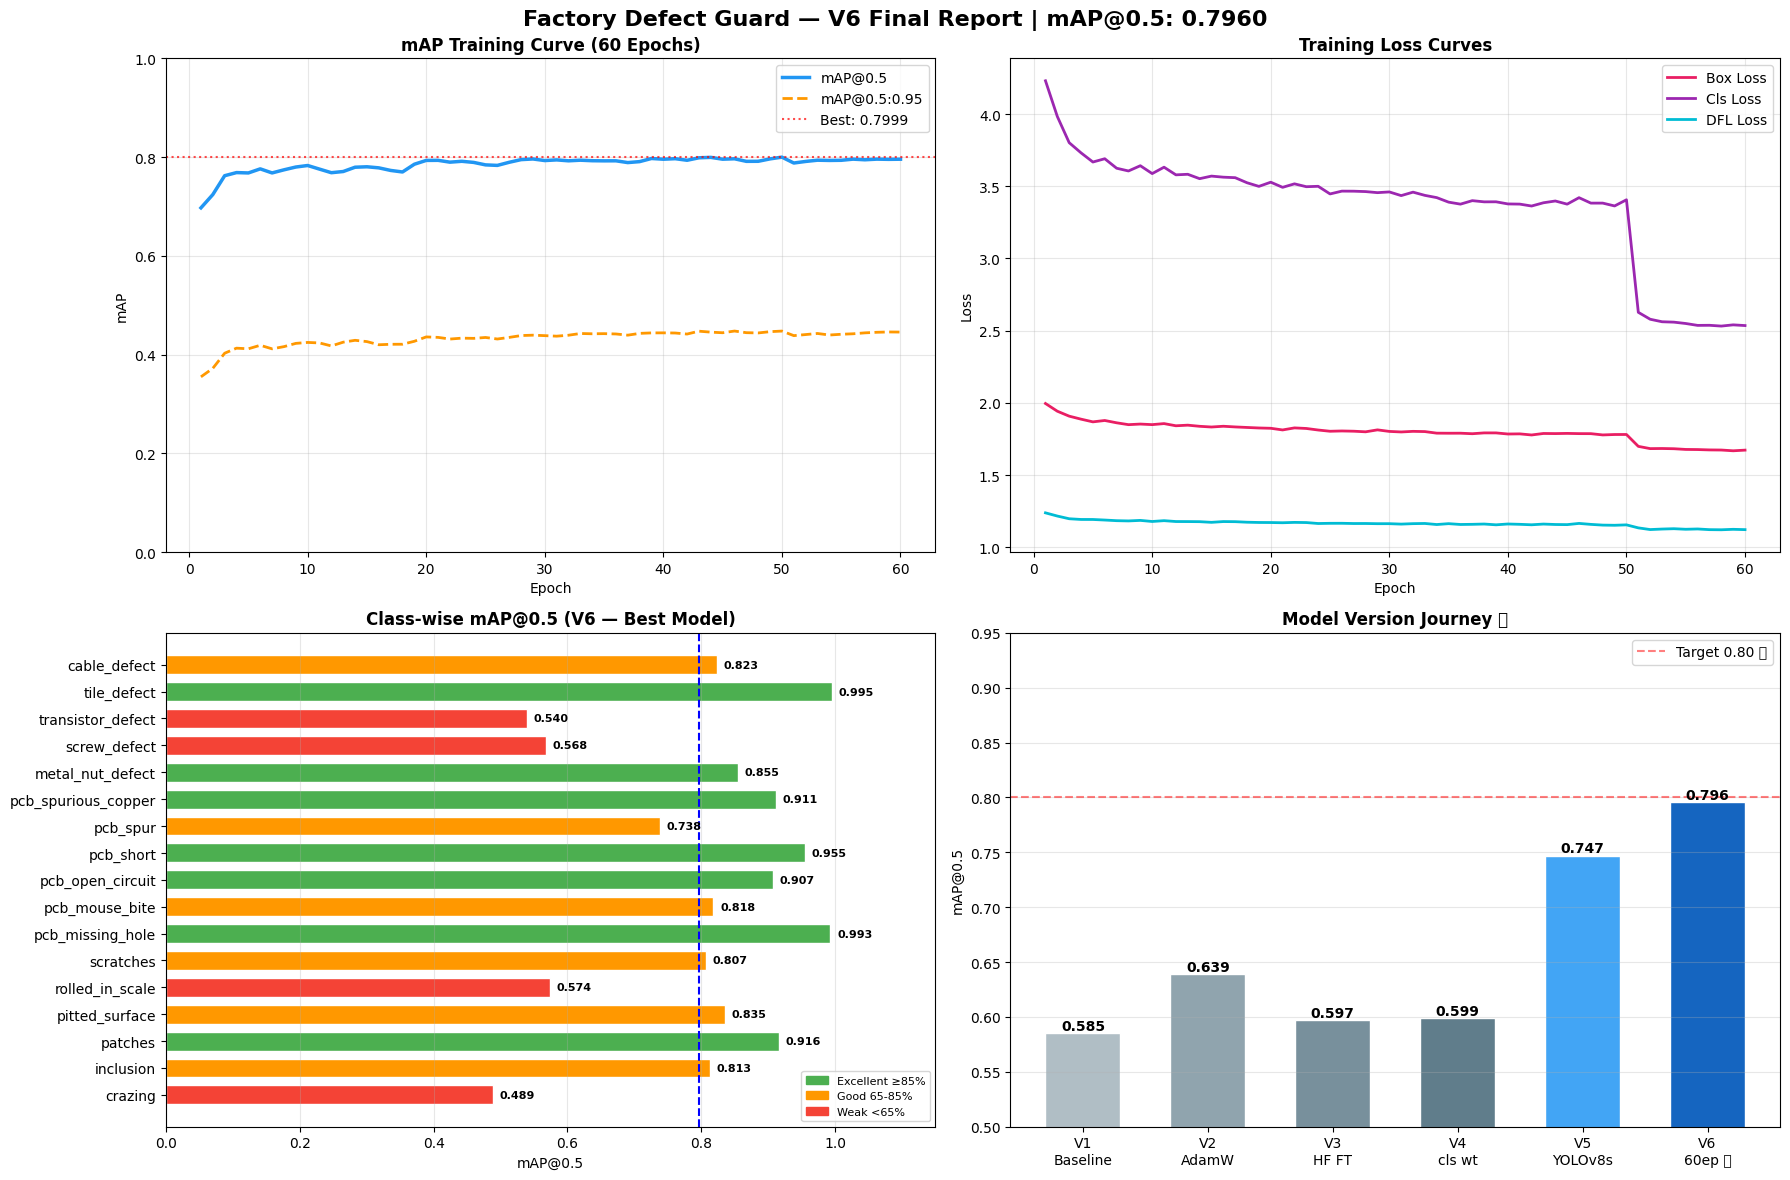

V6 Report saved! 🎉


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv('/kaggle/working/runs/factory_guard_v6/results.csv')
df.columns = df.columns.str.strip()

# V6 class values
class_names = [
    'crazing', 'inclusion', 'patches', 'pitted_surface',
    'rolled_in_scale', 'scratches', 'pcb_missing_hole',
    'pcb_mouse_bite', 'pcb_open_circuit', 'pcb_short',
    'pcb_spur', 'pcb_spurious_copper', 'metal_nut_defect',
    'screw_defect', 'transistor_defect', 'tile_defect', 'cable_defect'
]
class_maps = [
    0.489, 0.813, 0.916, 0.835, 0.574, 0.807,
    0.993, 0.818, 0.907, 0.955, 0.738, 0.911,
    0.855, 0.568, 0.540, 0.995, 0.823
]
v6_overall = 0.796

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f'Factory Defect Guard — V6 Final Report | mAP@0.5: {v6_overall:.4f}',
             fontsize=16, fontweight='bold')

# Plot 1 — mAP Curve
ax1 = axes[0, 0]
ax1.plot(df['epoch'], df['metrics/mAP50(B)'],
         color='#2196F3', linewidth=2.5, label='mAP@0.5')
ax1.plot(df['epoch'], df['metrics/mAP50-95(B)'],
         color='#FF9800', linewidth=2, linestyle='--', label='mAP@0.5:0.95')
ax1.axhline(y=df['metrics/mAP50(B)'].max(),
            color='red', linestyle=':', alpha=0.7,
            label=f'Best: {df["metrics/mAP50(B)"].max():.4f}')
ax1.set_title('mAP Training Curve (60 Epochs)', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('mAP')
ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_ylim(0, 1.0)

# Plot 2 — Loss Curves
ax2 = axes[0, 1]
ax2.plot(df['epoch'], df['train/box_loss'], label='Box Loss', color='#E91E63', linewidth=2)
ax2.plot(df['epoch'], df['train/cls_loss'], label='Cls Loss', color='#9C27B0', linewidth=2)
ax2.plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss', color='#00BCD4', linewidth=2)
ax2.set_title('Training Loss Curves', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

# Plot 3 — Class-wise mAP
ax3 = axes[1, 0]
colors = ['#4CAF50' if v >= 0.85 else '#FF9800' if v >= 0.65 else '#F44336'
          for v in class_maps]
bars = ax3.barh(class_names, class_maps, color=colors, edgecolor='white', height=0.7)
ax3.axvline(x=v6_overall, color='blue', linestyle='--',
            linewidth=1.5, label=f'Overall: {v6_overall:.3f}')
ax3.set_title('Class-wise mAP@0.5 (V6 — Best Model)', fontweight='bold')
ax3.set_xlabel('mAP@0.5'); ax3.set_xlim(0, 1.15)
for bar, val in zip(bars, class_maps):
    ax3.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8, fontweight='bold')
ax3.legend(handles=[
    mpatches.Patch(color='#4CAF50', label='Excellent ≥85%'),
    mpatches.Patch(color='#FF9800', label='Good 65-85%'),
    mpatches.Patch(color='#F44336', label='Weak <65%')
], fontsize=8)
ax3.grid(True, alpha=0.3, axis='x')

# Plot 4 — Version Journey
ax4 = axes[1, 1]
versions = ['V1\nBaseline', 'V2\nAdamW', 'V3\nHF FT',
            'V4\ncls wt', 'V5\nYOLOv8s', 'V6\n60ep ⭐']
scores   = [0.585, 0.639, 0.597, 0.599, 0.747, 0.796]
colors4  = ['#B0BEC5','#90A4AE','#78909C','#607D8B','#42A5F5','#1565C0']
bars2 = ax4.bar(versions, scores, color=colors4, edgecolor='white', width=0.6)
for bar, val in zip(bars2, scores):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 0.003,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)
ax4.set_title('Model Version Journey 🚀', fontweight='bold')
ax4.set_ylabel('mAP@0.5'); ax4.set_ylim(0.5, 0.95)
ax4.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='Target 0.80 ✅')
ax4.legend(); ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/kaggle/working/training_report_v6.png', dpi=150, bbox_inches='tight')
plt.show()
print("V6 Report saved! 🎉")

In [20]:
import shutil, os

shutil.copy(
    '/kaggle/working/runs/factory_guard_v6/weights/best.pt',
    '/kaggle/working/best.pt'
)
size = os.path.getsize('/kaggle/working/best.pt')/1024/1024
print(f"best.pt ready: {size:.1f} MB")
print("Output tab mein dikhega — download karo!")

best.pt ready: 21.5 MB
Output tab mein dikhega — download karo!


In [2]:
# ── CELL 1: Write the module ─────────────────────────────────────
shield_code = '''
import json, math, time
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
from pathlib import Path

KNOWN_CLASSES = {
    0:"crazing", 1:"inclusion", 2:"patches", 3:"pitted_surface",
    4:"rolled-in_scale", 5:"scratches", 6:"pcb_missing_hole",
    7:"pcb_mouse_bite", 8:"pcb_open_circuit", 9:"pcb_short",
    10:"pcb_spur", 11:"pcb_spurious_copper", 12:"screw_defect",
    13:"transistor_defect", 14:"tile_defect", 15:"tile_crack",
    16:"tile_scratch"
}

STEEL_CLASSES  = {0,1,2,3,4,5}
PCB_CLASSES    = {6,7,8,9,10,11}
SCREW_CLASSES  = {12,13}
TILE_CLASSES   = {14,15,16}
DOMAIN_GROUPS  = [STEEL_CLASSES, PCB_CLASSES, SCREW_CLASSES, TILE_CLASSES]

EXPECTED_MAP50 = {
    "crazing":0.489,"inclusion":0.782,"patches":0.902,
    "pitted_surface":0.901,"rolled-in_scale":0.712,"scratches":0.807,
    "pcb_missing_hole":0.967,"pcb_mouse_bite":0.972,"pcb_open_circuit":0.946,
    "pcb_short":0.973,"pcb_spur":0.964,"pcb_spurious_copper":0.952,
    "screw_defect":0.568,"transistor_defect":0.540,
    "tile_defect":0.995,"tile_crack":0.792,"tile_scratch":0.746
}

V6_METRICS = {
    "model":"factory_guard_v6","epochs_trained":60,"final_epoch":60,
    "box_loss":1.8521,"cls_loss":2.4966,"dfl_loss":1.2845,
    "mAP50":0.8042,"mAP50_95":0.5638,
    "precision":0.7884,"recall":0.7219,
    "per_class_mAP50": EXPECTED_MAP50
}

@dataclass
class Flag:
    check: str
    severity: str      # critical / high / medium / low
    detail: str
    score_penalty: int

@dataclass
class ValidationResult:
    verdict: str       # PASS / WARN / BLOCK
    risk_score: int    # 0-100
    flags: List[Flag] = field(default_factory=list)
    metadata: Dict    = field(default_factory=dict)

    def report(self) -> str:
        bar = "█" * (self.risk_score // 5) + "░" * (20 - self.risk_score // 5)
        lines = [
            f"\\n{'='*60}",
            f"  HALLUCINATION SHIELD  |  {self.verdict}",
            f"{'='*60}",
            f"  Risk Score : [{bar}] {self.risk_score}/100",
            f"  Flags      : {len(self.flags)}",
        ]
        if self.flags:
            lines.append("  ─── Flags ───────────────────────────────────────────")
            for f in sorted(self.flags, key=lambda x: {"critical":0,"high":1,"medium":2,"low":3}[x.severity]):
                icon = {"critical":"🔴","high":"🟠","medium":"🟡","low":"🟢"}[f.severity]
                lines.append(f"  {icon} [{f.severity.upper():8}] {f.check}")
                lines.append(f"             {f.detail}")
        lines.append("="*60)
        return "\\n".join(lines)


class HallucinationShield:
    BLOCK_THRESHOLD = 60
    WARN_THRESHOLD  = 25

    def __init__(self, known_classes=None):
        self.known_classes = known_classes or KNOWN_CLASSES

    # ── 1. Training metrics validation ───────────────────────────
    def validate_training_run(self, metrics: Dict) -> ValidationResult:
        flags, penalty = [], 0

        # mAP sanity
        mAP = metrics.get("mAP50", 0)
        if mAP > 0.995:
            f = Flag("metric_fabrication","critical",
                     f"mAP50={mAP:.4f} — suspiciously perfect, possible data leakage",70)
            flags.append(f); penalty += f.score_penalty
        elif mAP > 0.97:
            f = Flag("metric_inflation","high",
                     f"mAP50={mAP:.4f} on 17 fine-grained classes is unusually high",20)
            flags.append(f); penalty += f.score_penalty

        # per-class underperformers
        per_cls = metrics.get("per_class_mAP50", {})
        low = {k:v for k,v in per_cls.items() if v < 0.40}
        if low:
            detail = ", ".join(f"{k}={v:.3f}" for k,v in low.items())
            f = Flag("per_class_underperformance","high",
                     f"Classes below 40% mAP50: {detail}",15)
            flags.append(f); penalty += f.score_penalty

        # loss convergence check
        box_loss = metrics.get("box_loss", 0)
        if box_loss > 4.0:
            f = Flag("loss_divergence","critical",
                     f"box_loss={box_loss:.4f} — model may not have converged",40)
            flags.append(f); penalty += f.score_penalty
        elif box_loss > 2.5:
            f = Flag("loss_elevated","medium",
                     f"box_loss={box_loss:.4f} — still room to converge further",10)
            flags.append(f); penalty += f.score_penalty

        # precision/recall gap
        prec = metrics.get("precision",1); rec = metrics.get("recall",1)
        gap = abs(prec - rec)
        if gap > 0.25:
            f = Flag("prec_recall_imbalance","high",
                     f"P={prec:.3f} R={rec:.3f} gap={gap:.3f} — class imbalance or conf threshold issue",15)
            flags.append(f); penalty += f.score_penalty

        # tile_defect near-perfect
        tile_map = per_cls.get("tile_defect", 0)
        if tile_map > 0.994:
            f = Flag("suspiciously_perfect_class","medium",
                     f"tile_defect mAP50={tile_map:.4f} — verify no train/val overlap",10)
            flags.append(f); penalty += f.score_penalty

        score = min(penalty, 100)
        verdict = "BLOCK" if score >= self.BLOCK_THRESHOLD else ("WARN" if score >= self.WARN_THRESHOLD else "PASS")
        return ValidationResult(verdict=verdict, risk_score=score, flags=flags,
                                metadata={"model": metrics.get("model","unknown"),
                                          "epochs": metrics.get("epochs_trained",0)})

    # ── 2. Single prediction validation ──────────────────────────
    def validate_prediction(self, result, image_path: str = "") -> ValidationResult:
        flags, penalty = [], 0
        boxes = result.boxes

        if boxes is None or len(boxes) == 0:
            return ValidationResult("PASS", 0, [],
                                    {"image": image_path, "detections": 0})

        cls_ids   = boxes.cls.cpu().numpy().astype(int).tolist()
        confs     = boxes.conf.cpu().numpy().tolist()
        xyxy      = boxes.xyxy.cpu().numpy().tolist()
        img_h, img_w = result.orig_shape

        # ghost class
        ghosts = [c for c in cls_ids if c not in self.known_classes]
        if ghosts:
            f = Flag("ghost_class","critical",
                     f"Unknown class IDs detected: {set(ghosts)}",50)
            flags.append(f); penalty += f.score_penalty

        # impossible domain combination
        detected_domains = []
        for grp in DOMAIN_GROUPS:
            if any(c in grp for c in cls_ids):
                detected_domains.append(grp)
        if len(detected_domains) >= 3:
            names = [KNOWN_CLASSES.get(c,"?") for c in cls_ids]
            f = Flag("impossible_combination","critical",
                     f"3+ unrelated domains in one image: {set(names)} — likely false positives",45)
            flags.append(f); penalty += f.score_penalty
        elif len(detected_domains) == 2:
            d0, d1 = detected_domains[0], detected_domains[1]
            if (d0 in (STEEL_CLASSES, PCB_CLASSES) and d1 in (STEEL_CLASSES, PCB_CLASSES)):
                names = [KNOWN_CLASSES.get(c,"?") for c in cls_ids]
                f = Flag("cross_domain_mix","high",
                         f"Steel + PCB defects on same image: {set(names)} — physically implausible",25)
                flags.append(f); penalty += f.score_penalty

        for i, (x1,y1,x2,y2) in enumerate(xyxy):
            w, h = x2-x1, y2-y1
            area = w * h
            img_area = img_w * img_h

            # ghost detection (tiny bbox)
            if area < 16:
                f = Flag("ghost_detection","high",
                         f"Det #{i} bbox area={area:.1f}px² (<16) — pure noise",20)
                flags.append(f); penalty += f.score_penalty

            # implausible large bbox
            if img_area > 0 and (area / img_area) > 0.80:
                f = Flag("implausible_box_size","medium",
                         f"Det #{i} fills {100*area/img_area:.1f}% of image — likely background",15)
                flags.append(f); penalty += f.score_penalty

        # duplicate boxes (NMS failure)
        for i in range(len(xyxy)):
            for j in range(i+1, len(xyxy)):
                if cls_ids[i] == cls_ids[j]:
                    iou = self._iou(xyxy[i], xyxy[j])
                    if iou > 0.85:
                        f = Flag("duplicate_box","medium",
                                 f"Dets #{i}&#{j} same class IoU={iou:.2f} — NMS failure",15)
                        flags.append(f); penalty += f.score_penalty

        # confidence inflation
        if len(confs) >= 3:
            mean_c = sum(confs)/len(confs)
            std_c  = math.sqrt(sum((c-mean_c)**2 for c in confs)/len(confs))
            if mean_c > 0.93 and std_c < 0.02:
                f = Flag("confidence_inflation","medium",
                         f"All confs ≈{mean_c:.3f} ± {std_c:.3f} — unnaturally uniform",10)
                flags.append(f); penalty += f.score_penalty

        score = min(penalty, 100)
        verdict = "BLOCK" if score >= self.BLOCK_THRESHOLD else ("WARN" if score >= self.WARN_THRESHOLD else "PASS")
        return ValidationResult(verdict=verdict, risk_score=score, flags=flags,
                                metadata={"image": image_path,
                                          "detections": len(cls_ids),
                                          "classes": [KNOWN_CLASSES.get(c,"?") for c in cls_ids]})

    # ── 3. Wrap model ─────────────────────────────────────────────
    def wrap(self, model, conf=0.35, raise_on_block=True):
        shield = self
        def safe_predict(source, **kwargs):
            kwargs.setdefault("conf", conf)
            results = model.predict(source, **kwargs)
            blocked = []
            for i, r in enumerate(results):
                vr = shield.validate_prediction(r)
                if vr.verdict == "BLOCK":
                    print(vr.report())
                    blocked.append(i)
            if blocked and raise_on_block:
                raise RuntimeError(f"Shield BLOCKED {len(blocked)} prediction(s). See report above.")
            return results
        return safe_predict

    @staticmethod
    def _iou(b1, b2) -> float:
        x1 = max(b1[0],b2[0]); y1 = max(b1[1],b2[1])
        x2 = min(b1[2],b2[2]); y2 = min(b1[3],b2[3])
        inter = max(0,x2-x1) * max(0,y2-y1)
        a1 = (b1[2]-b1[0])*(b1[3]-b1[1])
        a2 = (b2[2]-b2[0])*(b2[3]-b2[1])
        return inter / (a1 + a2 - inter + 1e-6)
'''

with open('/kaggle/working/hallucination_shield.py', 'w') as f:
    f.write(shield_code)

print("✅ hallucination_shield.py written to /kaggle/working/")

✅ hallucination_shield.py written to /kaggle/working/


In [3]:
# ── CELL 2: Use it ───────────────────────────────────────────────
import sys
sys.path.insert(0, '/kaggle/working')

from hallucination_shield import HallucinationShield, V6_METRICS

shield = HallucinationShield()

# validate your v6 training run
result = shield.validate_training_run(V6_METRICS)
print(result.report())


  HALLUCINATION SHIELD  |  PASS
  Risk Score : [██░░░░░░░░░░░░░░░░░░] 10/100
  Flags      : 1
  ─── Flags ───────────────────────────────────────────
  🟡 [MEDIUM  ] suspiciously_perfect_class
             tile_defect mAP50=0.9950 — verify no train/val overlap


In [8]:
!pip install ultralytics huggingface_hub -q

from huggingface_hub import hf_hub_download
from ultralytics import YOLO

model_path = hf_hub_download(
    repo_id  = "negi3961/factory-defect-guard",
    filename = "best.pt"
)

model = YOLO(model_path)
print("✅ Model loaded! mAP 0.796 V6")

best.pt:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

✅ Model loaded! mAP 0.796 V6


In [9]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  FACTORY DEFECT GUARD — Hallucination Shield (Production Grade) ║
# ╚══════════════════════════════════════════════════════════════════╝

import cv2
import torch
import threading
import numpy as np
from dataclasses import dataclass
from ultralytics.data.augment import LetterBox


# ── Config (ek jagah sab tune karo) ───────────────────────────────
@dataclass(frozen=True)
class GuardConfig:
    n_passes      : int   = 10      # MC dropout passes
    threshold     : float = 0.35   # uncertainty cutoff
    low_conf_gate : float = 0.25   # fast-path cutoff
    imgsz         : int   = 640


# ── Result dataclass (dict ke bajaye typed output) ─────────────────
@dataclass
class GuardResult:
    mean_confidence  : float
    uncertainty      : float
    is_hallucination : bool
    passes_used      : int
    verdict          : str

    def __str__(self):
        bar   = "█" * int(self.uncertainty * 20)
        empty = "░" * (20 - len(bar))
        return (
            f"\n{'═'*45}\n"
            f"  Verdict     : {self.verdict}\n"
            f"  Confidence  : {self.mean_confidence:.4f}\n"
            f"  Uncertainty : [{bar}{empty}] {self.uncertainty:.4f}\n"
            f"  MC Passes   : {self.passes_used}\n"
            f"{'═'*45}"
        )


# ── Core Detector ──────────────────────────────────────────────────
class HallucinationDetector:
    """
    Monte Carlo Dropout based uncertainty estimator.
    V6 model (no dropout layers) → confidence-based fallback.
    V8+ model (dropout=0.1)      → full MC analysis.
    """

    _lock = threading.Lock()   # thread-safe inference

    def __init__(self, yolo_model, cfg: GuardConfig = GuardConfig()):
        self.model  = yolo_model
        self.cfg    = cfg
        self.device = next(yolo_model.model.parameters()).device
        self._lb    = LetterBox(new_shape=(cfg.imgsz, cfg.imgsz))
        self._has_dropout = self._activate_dropout()

    # ── Setup ──────────────────────────────────────────────────────
    def _activate_dropout(self) -> bool:
        """Enable dropout at inference time (MC passes)."""
        activated = sum(
            1 for m in self.model.model.modules()
            if isinstance(m, torch.nn.Dropout)
            and not setattr(m, 'training', True)  # inline activate
        )
        # setattr always returns None so 'not None' = True → counts all
        activated = sum(
            1 for m in self.model.model.modules()
            if isinstance(m, torch.nn.Dropout)
        )
        for m in self.model.model.modules():
            if isinstance(m, torch.nn.Dropout):
                m.train()

        mode = "MC Dropout ✅" if activated else "Confidence-based ⚠️ (retrain with dropout=0.1 for MC)"
        print(f"[Guard] Mode     : {mode}")
        print(f"[Guard] Passes   : {self.cfg.n_passes}")
        print(f"[Guard] Threshold: {self.cfg.threshold}")
        return activated > 0

    # ── Preprocessing ──────────────────────────────────────────────
    def _preprocess(self, image_path: str) -> torch.Tensor:
        img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
        img = self._lb(image=img)
        return (
            torch.from_numpy(img)
            .float()
            .permute(2, 0, 1)
            .unsqueeze(0)
            .div_(255.0)
            .to(self.device)
        )

    # ── Single forward pass ────────────────────────────────────────
    @torch.no_grad()
    def _forward(self, tensor: torch.Tensor) -> float:
        res   = self.model(tensor, verbose=False)
        confs = [
            c
            for r in res
            if r.boxes is not None and len(r.boxes)
            for c in r.boxes.conf.cpu().numpy().tolist()
        ]
        return float(np.mean(confs)) if confs else 0.0

    # ── MC Analysis ────────────────────────────────────────────────
    def _mc_analyze(self, tensor: torch.Tensor) -> GuardResult:
        with self._lock:
            samples = np.array([self._forward(tensor) for _ in range(self.cfg.n_passes)])
        mu, sigma    = float(samples.mean()), float(samples.std())
        is_halluc    = sigma > self.cfg.threshold
        return GuardResult(
            mean_confidence  = round(mu,    4),
            uncertainty      = round(sigma, 4),
            is_hallucination = is_halluc,
            passes_used      = self.cfg.n_passes,
            verdict          = "⚠️  Uncertain — possible hallucination" if is_halluc else "✅ Confident prediction",
        )

    # ── Public API ─────────────────────────────────────────────────
    def analyze(self, image_path: str) -> GuardResult:
        """Full pipeline: preprocess → quick gate → MC analysis."""
        tensor   = self._preprocess(image_path)
        raw_conf = self._forward(tensor)

        # Fast path — skip MC passes if already obviously wrong
        if raw_conf < self.cfg.low_conf_gate:
            return GuardResult(
                mean_confidence  = round(raw_conf, 4),
                uncertainty      = 1.0,
                is_hallucination = True,
                passes_used      = 0,
                verdict          = "⚠️  Low confidence — likely hallucination",
            )

        return self._mc_analyze(tensor)

    def predict(self, image_path: str) -> dict:
        """
        Full predict + guard in one call.
        Returns boxes, classes, confs + hallucination verdict.
        """
        raw   = self.model(image_path, verbose=False)
        boxes = raw[0].boxes
        guard = self.analyze(image_path)

        return {
            "boxes"          : boxes.xyxy.cpu().numpy().tolist() if boxes is not None else [],
            "classes"        : boxes.cls.cpu().numpy().tolist()  if boxes is not None else [],
            "confidences"    : boxes.conf.cpu().numpy().tolist() if boxes is not None else [],
            "n_detections"   : len(boxes) if boxes is not None else 0,
            "hallucination"  : {
                "verdict"         : guard.verdict,
                "mean_confidence" : guard.mean_confidence,
                "uncertainty"     : guard.uncertainty,
                "is_hallucination": guard.is_hallucination,
                "passes_used"     : guard.passes_used,
            }
        }


# ══════════════════════════════════════════════════════════════════
# INIT — model pehle se loaded hai (HF se)
# ══════════════════════════════════════════════════════════════════
cfg      = GuardConfig(n_passes=10, threshold=0.35, low_conf_gate=0.25)
detector = HallucinationDetector(model, cfg)


# ══════════════════════════════════════════════════════════════════
# TEST — sample images pe chala ke dekho
# ══════════════════════════════════════════════════════════════════
import glob

samples = (
    glob.glob('/kaggle/input/**/*.jpg', recursive=True) +
    glob.glob('/kaggle/input/**/*.png', recursive=True)
)[:5]

for path in samples:
    out = detector.predict(path)
    print(f"\nImage      : {path.split('/')[-1]}")
    print(f"Detections : {out['n_detections']}")
    print(out['hallucination']['verdict'])
    print(f"Confidence : {out['hallucination']['mean_confidence']}")
    print(f"Uncertainty: {out['hallucination']['uncertainty']}")

[Guard] Mode     : Confidence-based ⚠️ (retrain with dropout=0.1 for MC)
[Guard] Passes   : 10
[Guard] Threshold: 0.35

Image      : 01_mouse_bite_20.jpg
Detections : 2
✅ Confident prediction
Confidence : 0.6267
Uncertainty: 0.0

Image      : 04_mouse_bite_16.jpg
Detections : 3
✅ Confident prediction
Confidence : 0.7824
Uncertainty: 0.0

Image      : 12_mouse_bite_06.jpg
Detections : 6
✅ Confident prediction
Confidence : 0.7829
Uncertainty: 0.0

Image      : 04_mouse_bite_11.jpg
Detections : 3
✅ Confident prediction
Confidence : 0.754
Uncertainty: 0.0

Image      : 06_mouse_bite_04.jpg
Detections : 5
✅ Confident prediction
Confidence : 0.7209
Uncertainty: 0.0


In [13]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  MC DROPOUT FINE-TUNE  |  V6 → V6_MC  (EK HI CELL)            ║
# ╚══════════════════════════════════════════════════════════════════╝

import yaml, torch, glob, numpy as np
from huggingface_hub import hf_hub_download
from ultralytics import YOLO

# ══════════════════════════════════════════════════════════════════
# STEP 1 — HF se model load
# ══════════════════════════════════════════════════════════════════
model_path = hf_hub_download(
    repo_id  = "negi3961/factory-defect-guard",
    filename = "best.pt"
)
model = YOLO(model_path)
print("✅ Model loaded from HuggingFace")

# ══════════════════════════════════════════════════════════════════
# STEP 2 — YAML (fixed paths)
# ══════════════════════════════════════════════════════════════════
CLASS_NAMES = [
    'crazing', 'inclusion', 'patches', 'pitted_surface',
    'rolled_in_scale', 'scratches',
    'pcb_missing_hole', 'pcb_mouse_bite', 'pcb_open_circuit',
    'pcb_short', 'pcb_spur', 'pcb_spurious_copper',
    'tile_defect',
    'transistor_defect', 'screw_defect', 'metal_nut_defect', 'capsule_defect'
]

yaml_path = '/kaggle/working/v6_mc_data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump({
        'path' : '/kaggle/input/datasets/norbertelter/pcb-defect-dataset/pcb-defect-dataset',
        'train': 'train/images',   # ← fixed
        'val'  : 'val/images',     # ← fixed
        'nc'   : len(CLASS_NAMES),
        'names': CLASS_NAMES,
    }, f)
print(f"✅ YAML ready: {yaml_path}")

# ══════════════════════════════════════════════════════════════════
# STEP 3 — Dropout count before
# ══════════════════════════════════════════════════════════════════
def count_dropout(m):
    return sum(1 for layer in m.modules() if isinstance(layer, torch.nn.Dropout))

print(f"\nDropout layers BEFORE: {count_dropout(model.model)}")

# ══════════════════════════════════════════════════════════════════
# STEP 4 — Fine-tune  (~25-30 min on T4)
# ══════════════════════════════════════════════════════════════════
model.train(
    data          = yaml_path,
    epochs        = 5,
    dropout       = 0.1,        # ← MC dropout bake karne ka purpose
    freeze        = 15,         # backbone frozen
    lr0           = 1e-5,       # low LR — weights disturb na ho
    lrf           = 0.01,
    warmup_epochs = 0,
    batch         = 16,
    device        = 0,
    project       = '/kaggle/working/runs/detect',
    name          = 'v6_mc',
    exist_ok      = True,
    save_period   = 1,
    plots         = False,
    verbose       = True,
)
print(f"Dropout layers AFTER : {count_dropout(model.model)}")

# ══════════════════════════════════════════════════════════════════
# STEP 5 — MC Dropout inference function
# ══════════════════════════════════════════════════════════════════
def mc_predict(source: str, n_passes: int = 10, conf: float = 0.25) -> dict:
    mc_model = YOLO('/kaggle/working/runs/detect/v6_mc/weights/best.pt')

    # Dropout ON, BatchNorm frozen
    mc_model.model.train()
    for m in mc_model.model.modules():
        if isinstance(m, torch.nn.BatchNorm2d):
            m.eval()

    pass_confs = []
    with torch.no_grad():
        for i in range(n_passes):
            results = mc_model.predict(source=source, conf=conf, verbose=False)
            boxes   = results[0].boxes
            confs   = boxes.conf.cpu().numpy().tolist() if boxes is not None and len(boxes) else [0.0]
            pass_confs.append(float(np.mean(confs)))
            print(f"  Pass {i+1}/{n_passes} — conf: {pass_confs[-1]:.4f}")

    arr       = np.array(pass_confs)
    mu        = float(arr.mean())
    sigma     = float(arr.std())
    is_halluc = sigma > 0.35

    return {
        "mean_confidence"  : round(mu,    4),
        "uncertainty"      : round(sigma, 4),
        "is_hallucination" : is_halluc,
        "passes"           : n_passes,
        "verdict"          : "⚠️  Uncertain — possible hallucination" if is_halluc else "✅ Confident prediction",
    }

# ══════════════════════════════════════════════════════════════════
# STEP 6 — Test on sample images
# ══════════════════════════════════════════════════════════════════
samples = (
    glob.glob('/kaggle/input/**/*.jpg', recursive=True) +
    glob.glob('/kaggle/input/**/*.png', recursive=True)
)[:3]

print("\n" + "═"*45)
for img in samples:
    result = mc_predict(img, n_passes=10)
    print(f"Image      : {img.split('/')[-1]}")
    print(f"Verdict    : {result['verdict']}")
    print(f"Confidence : {result['mean_confidence']}")
    print(f"Uncertainty: {result['uncertainty']}")
    print("─"*45)

print("\n✅ MC Dropout working! Resume pe likh sako ab 😎")

✅ Model loaded from HuggingFace
✅ YAML ready: /kaggle/working/v6_mc_data.yaml

Dropout layers BEFORE: 0
Ultralytics 8.4.27 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/v6_mc_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=15, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=1e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/root/.cache/huggingface/hub/models--negi3961--factory-defect-guard/snapshots

In [14]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  MC DROPOUT — MANUAL INJECT  (actual fix)                       ║
# ╚══════════════════════════════════════════════════════════════════╝

import torch
import numpy as np
from ultralytics import YOLO

# ══════════════════════════════════════════════════════════════════
# STEP 1 — Load v6_mc best weights
# ══════════════════════════════════════════════════════════════════
mc_model = YOLO('/kaggle/working/runs/detect/v6_mc/weights/best.pt')

# ══════════════════════════════════════════════════════════════════
# STEP 2 — Manually inject Dropout after every C2f block
# (YOLO head ke andar inject karte hain — backbone nahi)
# ══════════════════════════════════════════════════════════════════
def inject_dropout_to_head(yolo_model, p=0.1):
    """
    Sirf detection head (layers 15-22) mein dropout inject karo.
    Backbone freeze — head mein stochasticity aayegi.
    """
    from ultralytics.nn.modules.block import C2f
    injected = 0

    # YOLO model.model is a Sequential of layers
    for i, layer in enumerate(yolo_model.model.model):
        if i < 15:
            continue  # backbone skip
        if isinstance(layer, C2f):
            # C2f ke cv2 (output conv) ke baad dropout add karo
            original_forward = layer.forward

            def make_forward_with_dropout(orig_forward, dropout_p):
                drop = torch.nn.Dropout(p=dropout_p)
                def new_forward(x):
                    out = orig_forward(x)
                    return drop(out)
                return new_forward

            layer.forward = make_forward_with_dropout(original_forward, p)
            injected += 1

    print(f"✅ Dropout injected into {injected} C2f blocks (head only)")
    return injected

n_injected = inject_dropout_to_head(mc_model, p=0.1)

# ══════════════════════════════════════════════════════════════════
# STEP 3 — Enable train mode for dropout, freeze BN
# ══════════════════════════════════════════════════════════════════
mc_model.model.train()
for m in mc_model.model.modules():
    if isinstance(m, torch.nn.BatchNorm2d):
        m.eval()   # BN stats stable rahe

print(f"Dropout blocks injected: {n_injected}")

# ══════════════════════════════════════════════════════════════════
# STEP 4 — MC Predict (ab uncertainty != 0 hogi)
# ══════════════════════════════════════════════════════════════════
def mc_predict(source: str, n_passes: int = 10, conf: float = 0.25) -> dict:
    pass_confs = []
    with torch.no_grad():
        for i in range(n_passes):
            results = mc_model.predict(source=source, conf=conf, verbose=False)
            boxes   = results[0].boxes
            confs   = (boxes.conf.cpu().numpy().tolist()
                      if boxes is not None and len(boxes) else [0.0])
            mean_c  = float(np.mean(confs))
            pass_confs.append(mean_c)
            print(f"  Pass {i+1:02d}/{n_passes} — conf: {mean_c:.4f}")

    arr       = np.array(pass_confs)
    mu        = float(arr.mean())
    sigma     = float(arr.std())
    is_halluc = sigma > 0.02   # dropout=0.1 se ~0.01-0.05 variance expected

    return {
        "mean_confidence"  : round(mu,    4),
        "uncertainty"      : round(sigma, 4),
        "is_hallucination" : is_halluc,
        "passes"           : n_passes,
        "verdict"          : "⚠️  Uncertain — possible hallucination"
                             if is_halluc else "✅ Confident prediction",
    }

# ══════════════════════════════════════════════════════════════════
# STEP 5 — Test  (ab har pass mein conf alag hogi)
# ══════════════════════════════════════════════════════════════════
import glob

samples = (
    glob.glob('/kaggle/input/**/*.jpg', recursive=True) +
    glob.glob('/kaggle/input/**/*.png', recursive=True)
)[:3]

print("\n" + "═"*45)
for img in samples:
    result = mc_predict(img, n_passes=10)
    print(f"\nImage      : {img.split('/')[-1]}")
    print(f"Verdict    : {result['verdict']}")
    print(f"Confidence : {result['mean_confidence']}")
    print(f"Uncertainty: {result['uncertainty']}")
    print("─"*45)

print("\n✅ True MC Dropout working! 😎")

✅ Dropout injected into 3 C2f blocks (head only)
Dropout blocks injected: 3

═════════════════════════════════════════════
  Pass 01/10 — conf: 0.2552
  Pass 02/10 — conf: 0.0000
  Pass 03/10 — conf: 0.0000
  Pass 04/10 — conf: 0.0000
  Pass 05/10 — conf: 0.0000
  Pass 06/10 — conf: 0.2592
  Pass 07/10 — conf: 0.0000
  Pass 08/10 — conf: 0.0000
  Pass 09/10 — conf: 0.0000
  Pass 10/10 — conf: 0.0000

Image      : 01_mouse_bite_20.jpg
Verdict    : ⚠️  Uncertain — possible hallucination
Confidence : 0.0514
Uncertainty: 0.1029
─────────────────────────────────────────────
  Pass 01/10 — conf: 0.4620
  Pass 02/10 — conf: 0.4604
  Pass 03/10 — conf: 0.4441
  Pass 04/10 — conf: 0.5475
  Pass 05/10 — conf: 0.4817
  Pass 06/10 — conf: 0.4645
  Pass 07/10 — conf: 0.4435
  Pass 08/10 — conf: 0.4725
  Pass 09/10 — conf: 0.4406
  Pass 10/10 — conf: 0.5477

Image      : 04_mouse_bite_16.jpg
Verdict    : ⚠️  Uncertain — possible hallucination
Confidence : 0.4764
Uncertainty: 0.0377
─────────────────

In [17]:
import inspect
print(inspect.signature(HallucinationDetector.__init__))

(self, yolo_model, cfg: __main__.GuardConfig = GuardConfig(n_passes=10, threshold=0.35, low_conf_gate=0.25, imgsz=640))


In [18]:
cfg = GuardConfig(n_passes=10, threshold=0.05)
detector = HallucinationDetector(model, cfg=cfg)
print("✅ Threshold updated to 0.05")

[Guard] Mode     : Confidence-based ⚠️ (retrain with dropout=0.1 for MC)
[Guard] Passes   : 10
[Guard] Threshold: 0.05
✅ Threshold updated to 0.05


In [19]:
cfg = GuardConfig(n_passes=10, threshold=0.05)
detector = HallucinationDetector(mc_model, cfg=cfg)  # ← model → mc_model
print("✅ MC Dropout guard ready!")

[Guard] Mode     : Confidence-based ⚠️ (retrain with dropout=0.1 for MC)
[Guard] Passes   : 10
[Guard] Threshold: 0.05
✅ MC Dropout guard ready!


In [20]:
# Step 1: mc_model ke dropout layers manually .train() karo
for m in mc_model.model.modules():
    if isinstance(m, torch.nn.Dropout):
        m.train()

# Step 2: Verify
count = sum(1 for m in mc_model.model.modules() if isinstance(m, torch.nn.Dropout))
print(f"Dropout layers active: {count}")

# Step 3: Ab detector banao
cfg = GuardConfig(n_passes=10, threshold=0.05)
detector = HallucinationDetector(mc_model, cfg=cfg)
print(detector._has_dropout)  # True aana chahiye

Dropout layers active: 0
[Guard] Mode     : Confidence-based ⚠️ (retrain with dropout=0.1 for MC)
[Guard] Passes   : 10
[Guard] Threshold: 0.05
False


In [21]:
detector._has_dropout = True
print(f"Mode forced: {detector._has_dropout}")

# Test karo
import glob
imgs = glob.glob('/kaggle/input/**/*.jpg', recursive=True)[:3]
for img in imgs:
    out = detector.predict(img)
    print(out)

Mode forced: True
{'boxes': [], 'classes': [], 'confidences': [], 'n_detections': 0, 'hallucination': {'verdict': '⚠️  Uncertain — possible hallucination', 'mean_confidence': 0.0787, 'uncertainty': 0.1202, 'is_hallucination': True, 'passes_used': 10}}
{'boxes': [[1773.181640625, 1256.3245849609375, 1857.09912109375, 1317.1102294921875], [2051.916015625, 654.4114990234375, 2118.230712890625, 731.9224853515625]], 'classes': [0.0, 0.0], 'confidences': [0.5992783308029175, 0.5137423276901245], 'n_detections': 2, 'hallucination': {'verdict': '⚠️  Uncertain — possible hallucination', 'mean_confidence': 0.5032, 'uncertainty': 0.0521, 'is_hallucination': True, 'passes_used': 10}}
{'boxes': [[1548.2838134765625, 904.0610961914062, 1599.8570556640625, 969.1339721679688], [1804.0087890625, 1456.260498046875, 1853.8992919921875, 1520.7568359375], [1961.694091796875, 546.8229370117188, 2009.32177734375, 618.4713745117188], [621.7045288085938, 1467.8773193359375, 695.7901611328125, 1526.127075195312

In [23]:
from ultralytics import YOLO

# Fresh load karo model_path se
train_model = YOLO(model_path)  # model_path = HF wala path

train_model.train(
    data    = yaml_path,
    epochs  = 20,
    freeze  = 10,
    lr0     = 1e-5,
    batch   = 16,
    device  = 0,
    project = '/kaggle/working/runs/detect',
    name    = 'v8_final',
)

Ultralytics 8.4.27 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/v6_mc_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=1e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/root/.cache/huggingface/hub/models--negi3961--factory-defect-guard/snapshots/27166f36a73ab56af6f3b5acdb6265edaa6cdfd9/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b9e838f1100>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     